In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

np.random.seed(101)
num_orders = 2000

start_date = datetime(2025, 1, 1)
order_dates = [start_date + timedelta(days=int(np.random.randint(0, 365))) for _ in range(num_orders)]
products = ['Laptop', 'Smartphone', 'Wireless Headphones', 'Smart Watch', 'Tablet']
categories = ['Electronics', 'Electronics', 'Accessories', 'Accessories', 'Electronics']
prices = [1200, 800, 150, 250, 450]

order_data = []
for i in range(num_orders):
    prod_idx = np.random.randint(0, 5)
    qty = np.random.randint(1, 4)
    revenue = prices[prod_idx] * qty
    order_data.append((
        f"ORD_{10000+i}",
        order_dates[i].strftime('%Y-%m-%d'),
        products[prod_idx],
        categories[prod_idx],
        qty,
        revenue
    ))

df_orders = pd.DataFrame(order_data, columns=['OrderID', 'OrderDate', 'Product', 'Category', 'Quantity', 'Revenue'])
conn = sqlite3.connect(':memory:')
df_orders.to_sql('sales_transactions', conn, index=False, if_exists='replace')

sql_query = """
SELECT
    strftime('%m', OrderDate) as Month,
    SUM(Quantity) as Total_Units_Sold,
    SUM(Revenue) as Total_Revenue
FROM sales_transactions
GROUP BY Month
ORDER BY Month;
"""

df_monthly_sales = pd.read_sql_query(sql_query, conn)
print("=== SQL Pipeline Execution Successful ===")
print(df_monthly_sales.head(12))

=== SQL Pipeline Execution Successful ===
   Month  Total_Units_Sold  Total_Revenue
0     01               370         218150
1     02               313         177200
2     03               364         208350
3     04               328         187800
4     05               333         190400
5     06               320         186950
6     07               363         188200
7     08               309         173400
8     09               346         182200
9     10               369         203350
10    11               353         214750
11    12               345         195100


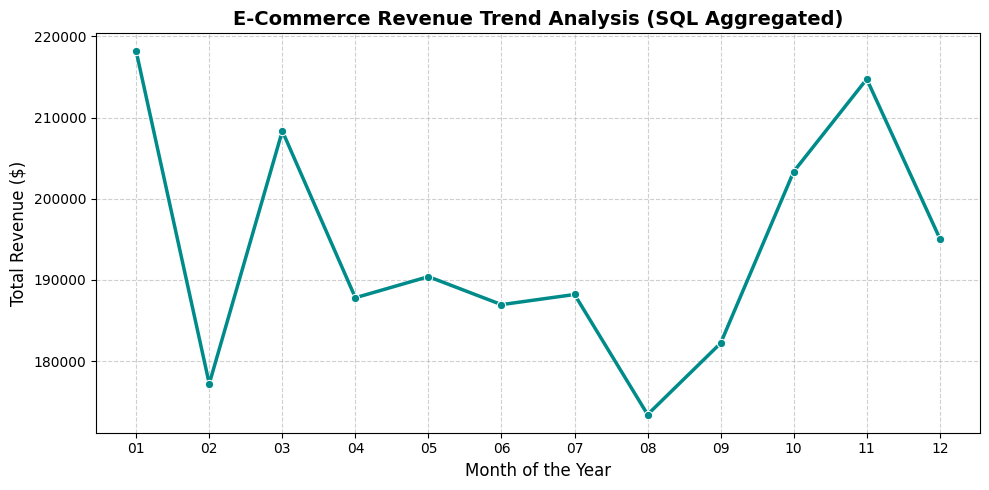

Analytics visualization successfully saved as 'ecommerce_sales_trend.png'


In [2]:
# Set up plotting style
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_monthly_sales, x='Month', y='Total_Revenue', marker='o', color='DarkCyan', linewidth=2.5)

plt.title('E-Commerce Revenue Trend Analysis (SQL Aggregated)', fontsize=14, fontweight='bold')
plt.xlabel('Month of the Year', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Save the visualization locally for your GitHub portfolio
plt.savefig('ecommerce_sales_trend.png', dpi=300)
plt.show()
print("Analytics visualization successfully saved as 'ecommerce_sales_trend.png'")